<a href="https://colab.research.google.com/github/tejasafk/f1-performance-insights/blob/main/F1Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Formula 1 dataset
df = pd.read_csv('/content/Formula1_2025Season_RaceResults.csv')
df

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,Set Fastest Lap,Fastest Lap Time
0,Australia,1,4,Lando Norris,McLaren Mercedes,1,57,1:42:06.304,25,Yes,1:22.167
1,Australia,2,1,Max Verstappen,Red Bull Racing Honda RBPT,3,57,+0.895,18,No,1:23.081
2,Australia,3,63,George Russell,Mercedes,4,57,+8.481,15,No,1:25.065
3,Australia,4,12,Kimi Antonelli,Mercedes,16,57,+10.135,12,No,1:24.901
4,Australia,5,23,Alexander Albon,Williams Mercedes,6,57,+12.773,10,No,1:24.597
...,...,...,...,...,...,...,...,...,...,...,...
474,Abu Dhabi,16,23,Alexander Albon,Williams Mercedes,17,58,+90.327,0,No,1:28.367
475,Abu Dhabi,17,6,Isack Hadjar,Racing Bulls Honda RBPT,9,57,+1 lap,0,No,1:29.375
476,Abu Dhabi,18,30,Liam Lawson,Racing Bulls Honda RBPT,13,57,+1 lap,0,No,1:28.886
477,Abu Dhabi,19,10,Pierre Gasly,Alpine Renault,19,57,+1 lap,0,No,1:27.767


In [ ]:
df['Position'] = pd.to_numeric(df['Position'], errors='coerce')
df

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,Set Fastest Lap,Fastest Lap Time
0,Australia,1.0,4,Lando Norris,McLaren Mercedes,1,57,1:42:06.304,25,Yes,1:22.167
1,Australia,2.0,1,Max Verstappen,Red Bull Racing Honda RBPT,3,57,+0.895,18,No,1:23.081
2,Australia,3.0,63,George Russell,Mercedes,4,57,+8.481,15,No,1:25.065
3,Australia,4.0,12,Kimi Antonelli,Mercedes,16,57,+10.135,12,No,1:24.901
4,Australia,5.0,23,Alexander Albon,Williams Mercedes,6,57,+12.773,10,No,1:24.597
...,...,...,...,...,...,...,...,...,...,...,...
474,Abu Dhabi,16.0,23,Alexander Albon,Williams Mercedes,17,58,+90.327,0,No,1:28.367
475,Abu Dhabi,17.0,6,Isack Hadjar,Racing Bulls Honda RBPT,9,57,+1 lap,0,No,1:29.375
476,Abu Dhabi,18.0,30,Liam Lawson,Racing Bulls Honda RBPT,13,57,+1 lap,0,No,1:28.886
477,Abu Dhabi,19.0,10,Pierre Gasly,Alpine Renault,19,57,+1 lap,0,No,1:27.767


In [ ]:
print("Initial data loading complete. Sample records:")
df.head()

Initial data loading complete. Sample records:


,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,Set Fastest Lap,Fastest Lap Time
0,Australia,1.0,4,Lando Norris,McLaren Mercedes,1,57,1:42:06.304,25,Yes,1:22.167
1,Australia,2.0,1,Max Verstappen,Red Bull Racing Honda RBPT,3,57,+0.895,18,No,1:23.081
2,Australia,3.0,63,George Russell,Mercedes,4,57,+8.481,15,No,1:25.065
3,Australia,4.0,12,Kimi Antonelli,Mercedes,16,57,+10.135,12,No,1:24.901
4,Australia,5.0,23,Alexander Albon,Williams Mercedes,6,57,+12.773,10,No,1:24.597


In [ ]:
df.tail()

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,Set Fastest Lap,Fastest Lap Time
474,Abu Dhabi,16.0,23,Alexander Albon,Williams Mercedes,17,58,+90.327,0,No,1:28.367
475,Abu Dhabi,17.0,6,Isack Hadjar,Racing Bulls Honda RBPT,9,57,+1 lap,0,No,1:29.375
476,Abu Dhabi,18.0,30,Liam Lawson,Racing Bulls Honda RBPT,13,57,+1 lap,0,No,1:28.886
477,Abu Dhabi,19.0,10,Pierre Gasly,Alpine Renault,19,57,+1 lap,0,No,1:27.767
478,Abu Dhabi,20.0,43,Franco Colapinto,Alpine Renault,20,57,+1 lap,0,No,1:27.710


In [ ]:
def convert_to_timedelta(time_str):
    if pd.isna(time_str) or ':' not in str(time_str):
        return pd.NaT

    parts = str(time_str).split(':')
    # Validate standard M:SS.mmm format
    if len(parts) == 2 and '.' not in parts[0]:
        try:
            return pd.to_timedelta(f"{parts[0]}m {parts[1]}s")
        except ValueError:
            return pd.NaT
    return pd.NaT

# Apply the function to transform raw strings into performance tracking objects
df['Fastest Lap Time (timedelta)'] = df['Fastest Lap Time'].apply(convert_to_timedelta)

print("Fastest Lap Time conversion complete. Check:")
df[['Fastest Lap Time', 'Fastest Lap Time (timedelta)']].dropna().head()

Fastest Lap Time conversion complete. Check:


,Fastest Lap Time,Fastest Lap Time (timedelta)
0,1:22.167,0 days 00:01:22.167000
1,1:23.081,0 days 00:01:23.081000
2,1:25.065,0 days 00:01:25.065000
3,1:24.901,0 days 00:01:24.901000
4,1:24.597,0 days 00:01:24.597000


In [ ]:
def clean_time_retired(val):
    val = str(val).strip()
    duration, time_gap, lap_gap, status = pd.NaT, np.nan, np.nan, None

    if val in ['DNF', 'DSQ', 'DNS']:
        status = val
    elif 'lap' in val.lower():
        # Parses out lap deficits (e.g., '+1 lap' -> 1)
        lap_gap = int(val.replace('+', '').split()[0])
    elif val.startswith('+'):
        # Parses out time intervals behind the leader (e.g., '+5.234' -> 5.234)
        time_gap = float(val.replace('+', ''))
    elif ':' in val:
        # Parses total race durations (e.g., '1:42:06.304' or '42:06.304')
        try:
            parts = val.split(':')
            if len(parts) == 3:
                duration = pd.to_timedelta(f"{parts[0]}h {parts[1]}m {parts[2]}s")
            elif len(parts) == 2:
                duration = pd.to_timedelta(f"{parts[0]}m {parts[1]}s")
        except ValueError:
            status = f"UNKNOWN: {val}"
    else:
        status = f"UNKNOWN: {val}"

    return pd.Series([duration, time_gap, lap_gap, status])

# Map the logic across rows into 4 explicit, distinct tracking features
df[['Race Duration', 'Time Gap (seconds)', 'Lap Gap', 'Race Status']] = df['Time/Retired'].apply(clean_time_retired)

print("Feature engineering complete. Parsed columns framework info:")
df[['Race Duration', 'Time Gap (seconds)', 'Lap Gap', 'Race Status']].info()

Feature engineering complete. Parsed columns framework info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Race Duration       24 non-null     object 
 1   Time Gap (seconds)  305 non-null    float64
 2   Lap Gap             89 non-null     float64
 3   Race Status         61 non-null     object 
dtypes: float64(2), object(2)
memory usage: 15.1+ KB


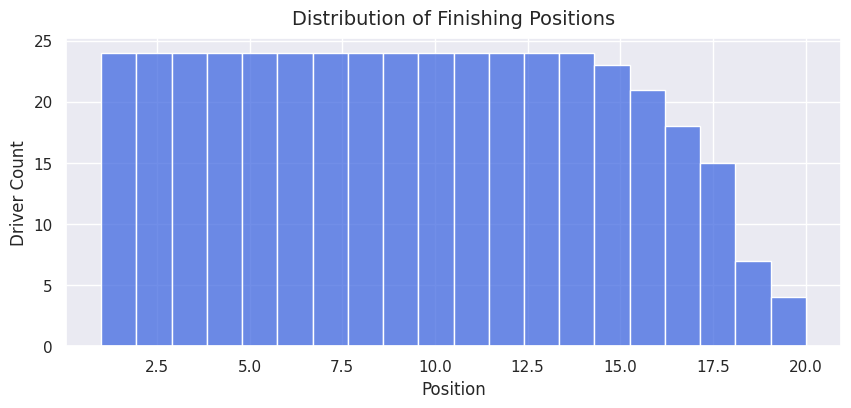

In [ ]:
# Setup professional plotting parameters
sns.set_theme(style="darkgrid")

# Plot A: Finishing Position Distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['Position'].dropna(), bins=int(df['Position'].max() or 20), kde=False, color='royalblue')
plt.title('Distribution of Finishing Positions', fontsize=14, pad=10)
plt.xlabel('Position')
plt.ylabel('Driver Count')
plt.show()

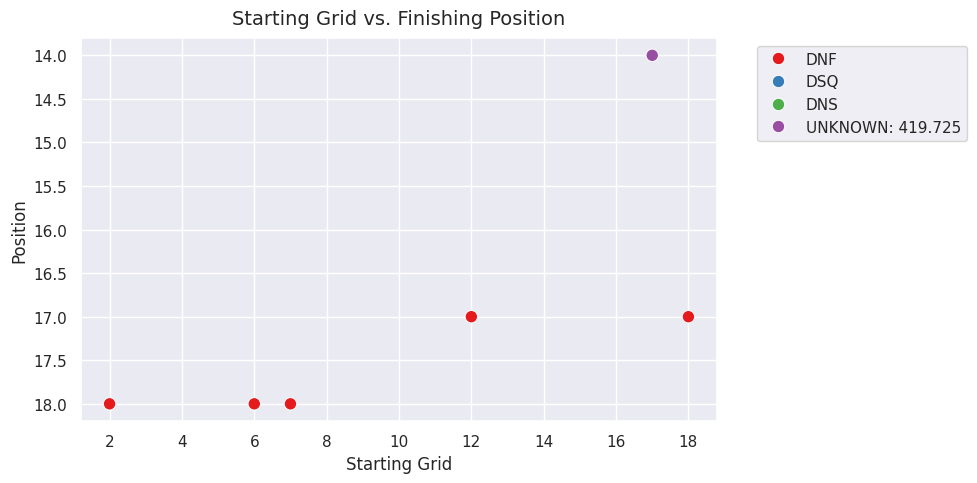

In [ ]:
# Plot B: Starting Grid vs. Ultimate Finishing Position
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Starting Grid', y='Position', hue='Race Status', data=df, palette='Set1', s=80)
plt.title('Starting Grid vs. Finishing Position', fontsize=14, pad=10)
plt.gca().invert_yaxis() # Traditional racing format (Position 1 at top)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()